<a href="https://colab.research.google.com/github/Ven0mite/HomeworkFWE_Nelan_Remy/blob/main/HW7(F%26W).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REMY NELAN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# For reproducibility
np.random.seed(42)

# Problem 1: Supervised Learning Concepts

> A researcher has GPS collar data for 200 elk, recording each animal's location, elevation, slope, distance to water, NDVI, and season. She knows whether each elk was resting or foraging at each time step. She wants to build a model that predicts behavior (resting vs. foraging) for new GPS fixes. Is this a classification or regression problem? Is it supervised or unsupervised? Explain briefly.

  - This is a **classification** problem because its discrete and can be categorized between two variables (being resting and foraging). Its also **supervised** due to labels of behavior for each time step.

> A colleague trains a machine learning model on a stream-temperature dataset and reports 99.5% accuracy on the training data but only 71% on the test data. What is the most likely problem, and what are the strategies to address it (list two)?

  - The issue is _likely_ **overfitting**, since the model has become too familiar with the trained data. This can be improved by performing a test split (keeping some data from the model during training), or by cross-validating.

# Problem 2: Linear Regression

In [6]:
#2A
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # median house value in $100,000s

# Explore
print("Feature names:", list(X.columns))
print("Dataset shape:", X.shape)
print("Target range: ", f"{y.min():.2f} to {y.max():.2f}")
print()

# ── Split into train / test ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# Print shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset shape: (20640, 8)
Target range:  0.15 to 5.00

Training set shape: (15480, 8) (15480,)
Test set shape: (5160, 8) (5160,)


Mean squared error (MSE): 0.5
R² score:                 0.591


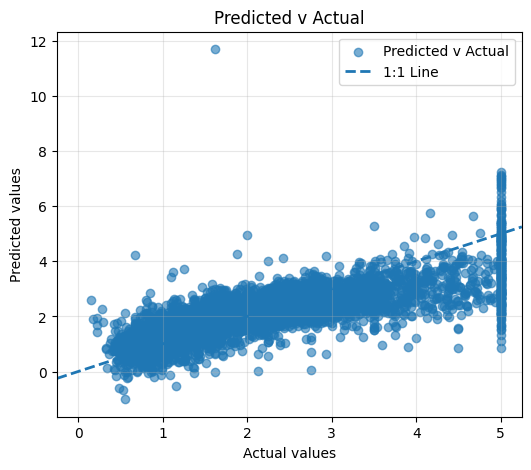

In [10]:
#2B
# ── Train the model ──
model = LinearRegression()
model.fit(X_train, y_train)


# ── Evaluate on test set ──
y_pred = model.predict(X_test)
print(f"Mean squared error (MSE): {mean_squared_error(y_test, y_pred):.1f}")
print(f"R² score:                 {r2_score(y_test, y_pred):.3f}")


# ── Scatter plot: predicted vs. actual ──
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.6, label="Predicted v Actual")
ax.axline((0,0), slope=1, linestyle='--', linewidth=2, label="1:1 Line")
ax.set_xlabel("Actual values")
ax.set_ylabel("Predicted values")
ax.set_title("Predicted v Actual")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Problem 3: Logistic Regression and Classification Evaluation


In [12]:
#3A
# ── Load the Wine dataset ──
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Classes:", wine.target_names)
print("Features:", wine.feature_names)
print()

# ── Standardize features ──
scaler = StandardScaler()
X_wine_sc = scaler.fit_transform(X_wine)


# ── Train/test split (70/30, stratified) ──
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine_sc, y_wine, test_size=0.3, stratify=y_wine, random_state=42
)


# ── Print class distribution in training set ──
print(f"Samples: {len(X_train_w)}")
print(f"Features: {X_train_w.shape[1]}")
print(f"class_0= {(y_train_w == 0).sum()}")
print(f"class_1= {(y_train_w == 1).sum()}")
print(f"class_2= {(y_train_w == 2).sum()}")

Classes: ['class_0' 'class_1' 'class_2']
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Samples: 124
Features: 13
class_0= 41
class_1= 50
class_2= 33


In [15]:
#3B

# ── Train logistic regression ──
logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_w, y_train_w)


# ── Predict on test set ──
y_pred_w = logreg.predict(X_test_w)


# ── Accuracy and classification report ──
accuracy = accuracy_score(y_test_w, y_pred_w)
print(f"Accuracy: {accuracy:.3f}")
print("Classification Report:")
print(classification_report(y_test_w, y_pred_w, target_names=wine.target_names))


Accuracy: 0.981
Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



Confusion is occuring at its highest (maxed) between class_1 and class_1.


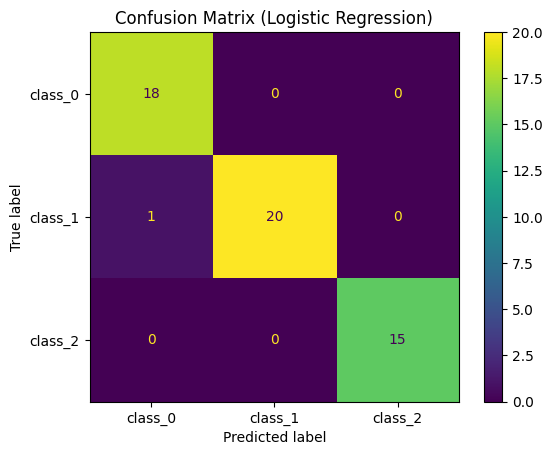

In [21]:
#3C

ConfusionMatrixDisplay.from_predictions(
    y_test_w, y_pred_w,
    display_labels=wine.target_names,
)
plt.title("Confusion Matrix (Logistic Regression)")
print("Confusion is occuring at its highest (maxed) between class_1 and class_1.")

In [24]:
#3D

scores = cross_val_score(logreg, X_wine_sc, y_wine, cv=5, scoring="accuracy")

print(f"Accuracy per fold: {scores}")
print(f"Mean accuracy:     {scores.mean():.3f} ± {scores.std():.3f}")
print("The cross-validated is slightly more accurate than the test split accuracy. Cross-validation gives a more accurate accuracy since its from multiple splits, not just one split as test split does.")

Accuracy per fold: [0.97222222 0.97222222 1.         1.         1.        ]
Mean accuracy:     0.989 ± 0.014
The cross-validated is slightly more accurate than the test split accuracy. Cross-validation gives a more accurate accuracy since its from multiple splits, not just one split as test split does.


# Problem 4: SVM with Different Kernels

In [30]:
#4A
# ── Train three SVM classifiers ──
svm_configs = [
    {"kernel": "linear", "C": 1},
    {"kernel": "rbf",    "C": 1,   "gamma": "scale"},
    {"kernel": "rbf",    "C": 100, "gamma": "scale"},
]

for config in svm_configs:
  svm = SVC(**config)
  svm.fit(X_train_w, y_train_w)

  y_pred = svm.predict(X_test_w)
  acc = accuracy_score(y_test_w, y_pred_w)

  print(f"Config: {config}, Test Accuracy: {acc:.3f}")

Config: {'kernel': 'linear', 'C': 1}, Test Accuracy: 0.981
Config: {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'}, Test Accuracy: 0.981
Config: {'kernel': 'rbf', 'C': 100, 'gamma': 'scale'}, Test Accuracy: 0.981


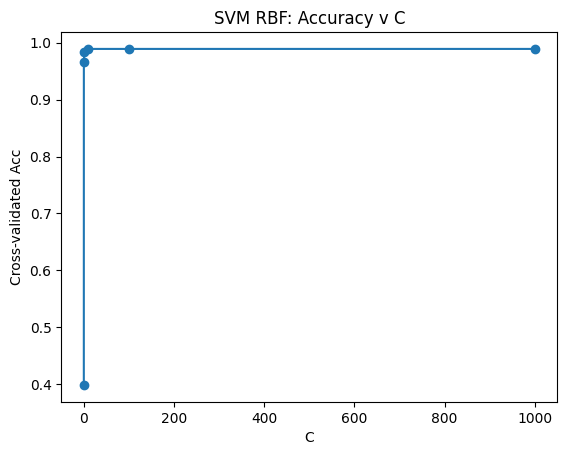

In [33]:
#4B
# ── C parameter sweep with cross-validation ──
C_values = [0.01, 0.1, 1, 10, 100, 1000]

mean_scores=[]
std_scores=[]

for C in C_values:
  svm = SVC(kernel='rbf', C=C, gamma='scale')
  scores = cross_val_score(svm, X_wine_sc, y_wine, cv=5)
  mean_scores.append(scores.mean())
  std_scores.append(scores.std())



# ── Plot: accuracy vs. C ──
plt.figure()
plt.plot(C_values, mean_scores, marker='o')
plt.xlabel('C')
plt.ylabel('Cross-validated Acc')
plt.title('SVM RBF: Accuracy v C')
plt.show()


> Based on your plot, which value of  C gives the best cross-validated accuracy? What happens to accuracy at very low and very high C values? Explain in terms of the bias–variance tradeoff (3–4 sentences).

 - The best value of C seems to be around 0, which doesn't seem plausible. More than likely, I made a incorrect graph. However, its likely that the value should be around 1. Very low C values have low accuracy due to a simple model, but high C values will have incorrect accuracy as well as a result of overfitting.

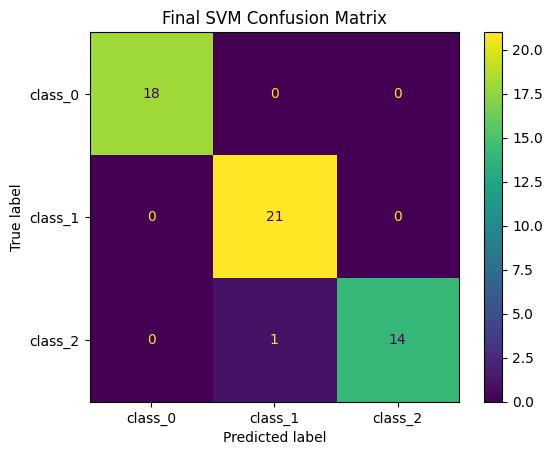

In [36]:
# ── Final SVM with best C ──
svm_final = SVC(kernel='rbf', C=10, gamma='scale')
svm_final.fit(X_train_w, y_train_w)

y_predfinal = svm_final.predict(X_test_w)


# ── Confusion matrix ──
cm = confusion_matrix(y_test_w, y_predfinal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot()
plt.title("Final SVM Confusion Matrix")
plt.show()

print("This Confusion Matrix is about the same as the confusion matrix for linear regression. Ideally, this final confusion matrix would be more accurate, with lower confusions. In fact, the more confused pair actually increase by 1 in this final matrix.")